In [10]:
import pandas as pd
import numpy as np
airline = pd.read_csv('aairline.csv') 
airline.info()

<class 'pandas.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [3]:
airline.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [4]:
airline.info()

<class 'pandas.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [5]:
airline.shape

(3999, 12)

In [6]:
airline.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [7]:
airline.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


<function matplotlib.pyplot.show(close=None, block=None)>

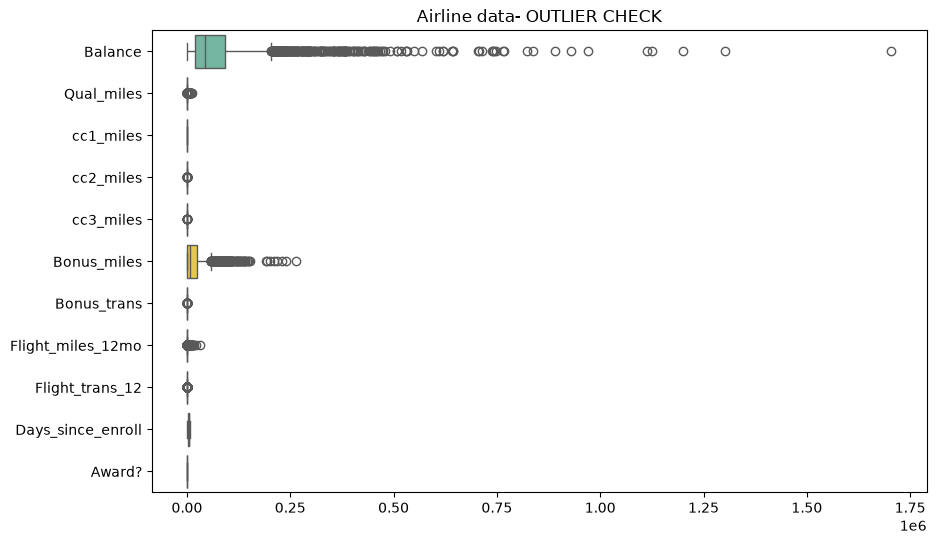

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.boxplot(data=airline.drop('ID#',axis=1),orient='h',palette='Set2')
plt.title('Airline data- OUTLIER CHECK')
plt.show

In [11]:
def cap_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return np.clip(series, lower_bound, upper_bound)
airline = airline.apply(cap_outliers)

In [12]:
from sklearn.preprocessing import StandardScaler
airline_clean=airline.drop('ID#',axis=1)
scale=StandardScaler()
airline_scaled=scale.fit_transform(airline_clean)
airline_scaled=pd.DataFrame(airline_scaled,columns=airline_clean.columns)

In [13]:
airline_scaled

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-0.607258,0.0,-0.769578,0.0,0.0,-0.843091,-1.148854,-0.604313,-0.626143,1.395454,-0.766919
1,-0.758947,0.0,-0.769578,0.0,0.0,-0.840822,-1.039133,-0.604313,-0.626143,1.379957,-0.766919
2,-0.382070,0.0,-0.769578,0.0,0.0,-0.624581,-0.819689,-0.604313,-0.626143,1.411920,-0.766919
3,-0.835106,0.0,-0.769578,0.0,0.0,-0.825052,-1.148854,-0.604313,-0.626143,1.372208,-0.766919
4,0.579265,0.0,1.409471,0.0,0.0,1.543191,1.594189,2.034489,2.020176,1.363975,1.303918
...,...,...,...,...,...,...,...,...,...,...,...
3994,-0.772038,0.0,-0.769578,0.0,0.0,-0.381007,-0.819689,0.074478,0.432384,-1.315120,1.303918
3995,0.010506,0.0,-0.769578,0.0,0.0,-0.798437,-0.709967,-0.604313,-0.626143,-1.318994,1.303918
3996,0.167530,0.0,0.683121,0.0,0.0,0.555335,-0.380802,-0.604313,-0.626143,-1.315604,1.303918
3997,-0.151188,0.0,-0.769578,0.0,0.0,-0.825052,-1.148854,1.092666,0.432384,-1.316088,-0.766919


In [14]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,random_state=42,n_init=10)
    kmeans.fit(airline_scaled)
    wcss.append(kmeans.inertia_)

<function matplotlib.pyplot.show(close=None, block=None)>

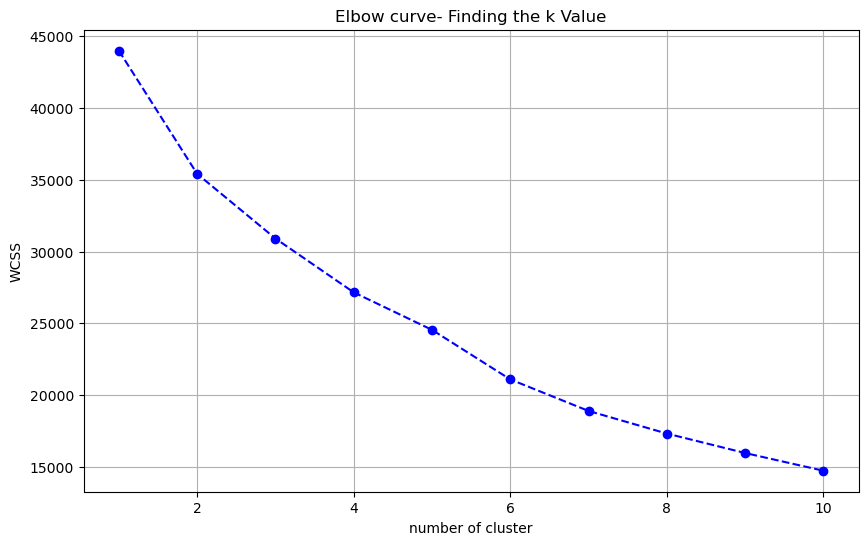

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
plt.plot(range(1,11),wcss,marker='o',linestyle='--',color='blue')
plt.title("Elbow curve- Finding the k Value")
plt.xlabel("number of cluster")
plt.ylabel('WCSS')
plt.grid(True)
plt.show

In [38]:
means_final=KMeans(n_clusters=4,random_state=42,n_init=10)
cluster_label=means_final.fit_predict(airline_scaled)
airline['KMeans_cluster']=cluster_label
print(airline['KMeans_cluster'].value_counts())
airline.head()

KMeans_cluster
1    2543
2    1273
3     168
0      15
Name: count, dtype: int64


,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_cluster
0,1,28143,0,1,1,1,174,1,0,0,7000,0,1
1,2,19244,0,1,1,1,215,2,0,0,6968,0,1
2,3,41354,0,1,1,1,4123,4,0,0,7034,0,1
3,4,14776,0,1,1,1,500,1,0,0,6952,0,1
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1,2


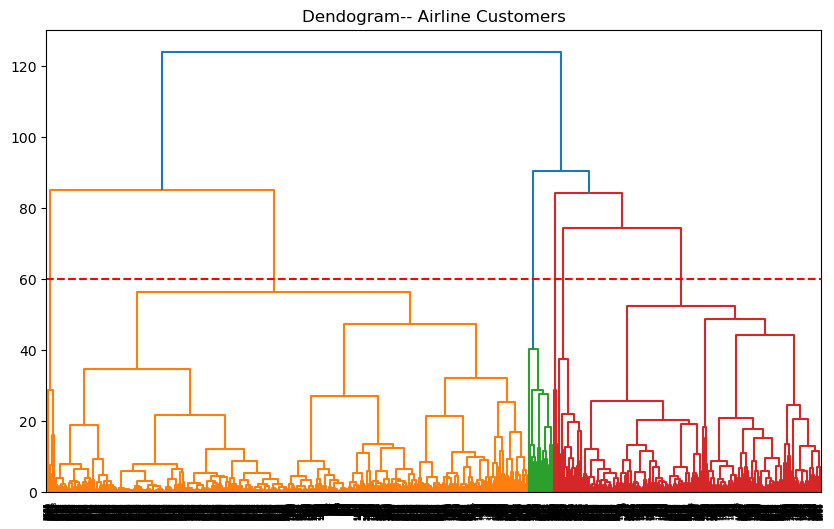

In [39]:
import scipy.cluster.hierarchy as shc
plt.figure(figsize=(10,6))
plt.title('Dendogram-- Airline Customers')
dend=shc.dendrogram(shc.linkage(airline_scaled,method='ward'))
plt.axhline(y=60,color='r',linestyle='--')
plt.show()

In [40]:
from sklearn.cluster import AgglomerativeClustering
hc_model = AgglomerativeClustering(n_clusters=6, metric='euclidean', linkage='ward')
hc_labels = hc_model.fit_predict(airline_scaled)
airline['Hierarchical_Cluster'] = hc_labels
print(airline['Hierarchical_Cluster'].value_counts())

Hierarchical_Cluster
0    2446
1    1232
5     130
2     130
3      43
4      18
Name: count, dtype: int64


In [41]:
from sklearn.cluster import DBSCAN
dbscan_model = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan_model.fit_predict(airline_scaled)
airline['DBSCAN_Cluster'] = dbscan_labels
print(airline['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    2411
 1    1250
-1     310
 2      15
 3       8
 4       5
Name: count, dtype: int64


In [42]:
from sklearn.metrics import silhouette_score
kmeans_score = silhouette_score(airline_scaled, airline['KMeans_cluster'])
print(f"K-Means Clustering Silhouette Score: {kmeans_score:.4f}")
dbscan_score = silhouette_score(airline_scaled, airline['DBSCAN_Cluster'])
print(f"DBSCAN Clustering Silhouette Score: {dbscan_score:.4f}")

K-Means Clustering Silhouette Score: 0.3092
DBSCAN Clustering Silhouette Score: 0.2537


## Conclusion & Comparative Analysis

In this assignment, we analyzed the EastWest Airlines customer dataset using three distinct unsupervised clustering algorithms: K-Means, Hierarchical, and DBSCAN. The objective was to identify natural customer segments based on their flight patterns and reward behaviors.

K-Means Clustering (K=4): The model effectively segmented the customers into 4 distinct groups. The customer base is heavily concentrated in two primary segments: Cluster 1 (2,543 passengers) and Cluster 2 (1,273 passengers). It also identified smaller, targeted groups, notably Cluster 3 (168 passengers) and a highly exclusive niche in Cluster 0 (15 passengers).

Hierarchical Clustering (K=6): Based on the structural linkages in the dendrogram, an optimal cut yielded 6 clusters. Consistent with the K-Means distribution, this method revealed a massive primary segment (Cluster 0: 2,446 passengers) and a secondary segment (Cluster 1: 1,232 passengers), while partitioning the remaining higher-variance customers into four smaller sub-groups.

DBSCAN: This density-based algorithm demonstrated its robustness by successfully identifying 310 data points as extreme outliers or "noise" (labeled as -1), which likely represent highly unusual flying behaviors. After isolating the noise, it formed 5 valid density clusters, primarily dominated by Cluster 0 (2,411 passengers) and Cluster 1 (1,250 passengers).

Performance Evaluation: Utilizing the Silhouette Score as our internal evaluation metric, K-Means achieved a score of 0.3092, outperforming DBSCAN's score of 0.2537.

Final Insight: K-Means clustering provided the most structurally coherent segmentation for this dataset. However, the consistency across all three models—consistently isolating a primary group of ~2,400 to 2,500 passengers and a secondary group of ~1,200 to 1,250 passengers—indicates a strong, natural behavioral divide among the airline's customer base (e.g., standard frequent flyers vs. highly active travelers).